In [2]:
import pandas as pd

df = pd.read_csv("../data/SuperStoreOrders.csv")

print(df.head())

          order_id order_date ship_date       ship_mode    customer_name  \
0     AG-2011-2040   1/1/2011  6/1/2011  Standard Class  Toby Braunhardt   
1    IN-2011-47883   1/1/2011  8/1/2011  Standard Class      Joseph Holt   
2     HU-2011-1220   1/1/2011  5/1/2011    Second Class    Annie Thurman   
3  IT-2011-3647632   1/1/2011  5/1/2011    Second Class     Eugene Moren   
4    IN-2011-47883   1/1/2011  8/1/2011  Standard Class      Joseph Holt   

       segment            state    country  market   region  ...  \
0     Consumer      Constantine    Algeria  Africa   Africa  ...   
1     Consumer  New South Wales  Australia    APAC  Oceania  ...   
2     Consumer         Budapest    Hungary    EMEA     EMEA  ...   
3  Home Office        Stockholm     Sweden      EU    North  ...   
4     Consumer  New South Wales  Australia    APAC  Oceania  ...   

          category sub_category                 product_name sales quantity  \
0  Office Supplies      Storage          Tenex Lockers,

# Data Cleaning & Visualization Project

## SuperStore Sales Analysis

This project focuses on cleaning, analyzing, and visualizing a SuperStore sales dataset using Python.

### Objectives
- Explore the raw dataset
- Handle missing values
- Remove duplicate records
- Detect and handle outliers
- Analyze sales and profit
- Create meaningful visualizations
- Identify important business insights

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import os

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
df = pd.read_csv("../data/SuperStoreOrders.csv")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 51290
Columns: 21


In [5]:
df.head()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,1/1/2011,6/1/2011,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Office Supplies,Storage,"Tenex Lockers, Blue",408,2,0.0,106.140,35.46,Medium,2011
1,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,3,0.1,36.036,9.72,Medium,2011
2,HU-2011-1220,1/1/2011,5/1/2011,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Office Supplies,Storage,"Tenex Box, Single Width",66,4,0.0,29.640,8.17,High,2011
3,IT-2011-3647632,1/1/2011,5/1/2011,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,Office Supplies,Paper,"Enermax Note Cards, Premium",45,3,0.5,-26.055,4.82,High,2011
4,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114,5,0.1,37.770,4.70,Medium,2011


In [6]:
df.shape

(51290, 21)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        51290 non-null  str    
 1   order_date      51290 non-null  str    
 2   ship_date       51290 non-null  str    
 3   ship_mode       51290 non-null  str    
 4   customer_name   51290 non-null  str    
 5   segment         51290 non-null  str    
 6   state           51290 non-null  str    
 7   country         51290 non-null  str    
 8   market          51290 non-null  str    
 9   region          51290 non-null  str    
 10  product_id      51290 non-null  str    
 11  category        51290 non-null  str    
 12  sub_category    51290 non-null  str    
 13  product_name    51290 non-null  str    
 14  sales           51290 non-null  str    
 15  quantity        51290 non-null  int64  
 16  discount        51290 non-null  float64
 17  profit          51290 non-null  float64
 1

In [8]:
df.describe()

,quantity,discount,profit,shipping_cost,year
count,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,3.476545,0.142908,28.641740,26.375915,2012.777208
std,2.278766,0.212280,174.424113,57.296804,1.098931
min,1.000000,0.000000,-6599.978000,0.000000,2011.000000
25%,2.000000,0.000000,0.000000,2.610000,2012.000000
50%,3.000000,0.000000,9.240000,7.790000,2013.000000
75%,5.000000,0.200000,36.810000,24.450000,2014.000000
max,14.000000,0.850000,8399.976000,933.570000,2014.000000


In [9]:
missing_values = df.isnull().sum()

print("Missing Values:")
print(missing_values[missing_values > 0])

Missing Values:
Series([], dtype: int64)


In [10]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [11]:
df = df.drop_duplicates()

print("Duplicates after cleaning:", df.duplicated().sum())

Duplicates after cleaning: 0


In [12]:
# Fill numerical missing values with median
numeric_columns = df.select_dtypes(include=np.number).columns

for column in numeric_columns:
    df[column] = df[column].fillna(df[column].median())

# Fill text/categorical missing values with mode
categorical_columns = df.select_dtypes(include="object").columns

for column in categorical_columns:
    if df[column].isnull().sum() > 0:
        df[column] = df[column].fillna(df[column].mode()[0])

print("Missing values handled successfully!")
print(df.isnull().sum().sum(), "missing values remaining")

Missing values handled successfully!
0 missing values remaining


C:\Users\sridhar\AppData\Local\Temp\ipykernel_21540\1300230341.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include="object").columns


In [15]:
df["order_date"] = pd.to_datetime(df["order_date"], errors="coerce")
df["ship_date"] = pd.to_datetime(df["ship_date"], errors="coerce")

print("Date columns converted successfully!")

Date columns converted successfully!


In [16]:
print("Dataset Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Dataset Shape: (51290, 21)

Missing Values:
order_id              0
order_date        31223
ship_date         31456
ship_mode             0
customer_name         0
segment               0
state                 0
country               0
market                0
region                0
product_id            0
category              0
sub_category          0
product_name          0
sales                 0
quantity              0
discount              0
profit                0
shipping_cost         0
order_priority        0
year                  0
dtype: int64

Duplicate Rows: 0


In [17]:
# Check missing dates after conversion

print("Missing Order Dates:", df["order_date"].isna().sum())
print("Missing Ship Dates:", df["ship_date"].isna().sum())

# Keep missing dates as NaT instead of inventing dates
print("\nDate values will be excluded only from time-based analysis.")

Missing Order Dates: 31223
Missing Ship Dates: 31456

Date values will be excluded only from time-based analysis.


In [18]:
numeric_columns = df.select_dtypes(include=np.number).columns

print("Numerical Columns:")
print(numeric_columns.tolist())

Numerical Columns:
['quantity', 'discount', 'profit', 'shipping_cost', 'year']


In [19]:
print(df[numeric_columns].describe())

           quantity      discount        profit  shipping_cost          year
count  51290.000000  51290.000000  51290.000000   51290.000000  51290.000000
mean       3.476545      0.142908     28.641740      26.375915   2012.777208
std        2.278766      0.212280    174.424113      57.296804      1.098931
min        1.000000      0.000000  -6599.978000       0.000000   2011.000000
25%        2.000000      0.000000      0.000000       2.610000   2012.000000
50%        3.000000      0.000000      9.240000       7.790000   2013.000000
75%        5.000000      0.200000     36.810000      24.450000   2014.000000
max       14.000000      0.850000   8399.976000     933.570000   2014.000000


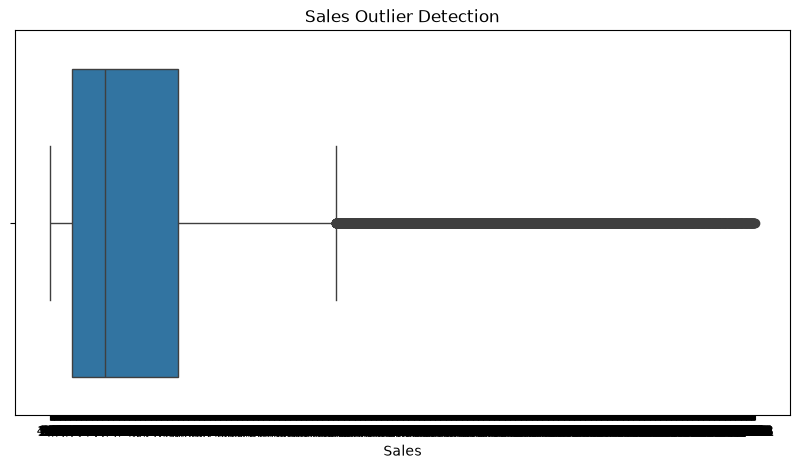

In [20]:
plt.figure(figsize=(10, 5))

sns.boxplot(x=df["sales"])

plt.title("Sales Outlier Detection")
plt.xlabel("Sales")

plt.show()

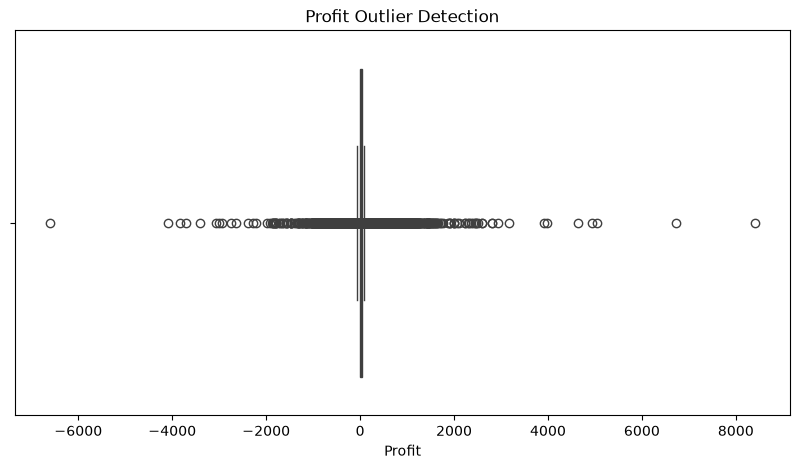

In [21]:
plt.figure(figsize=(10, 5))

sns.boxplot(x=df["profit"])

plt.title("Profit Outlier Detection")
plt.xlabel("Profit")

plt.show()

In [22]:
Q1 = df["sales"].quantile(0.25)
Q3 = df["sales"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Sales Lower Bound:", lower_bound)
print("Sales Upper Bound:", upper_bound)

sales_outliers = (
    (df["sales"] < lower_bound) |
    (df["sales"] > upper_bound)
).sum()

print("Sales Outliers:", sales_outliers)

TypeError: unsupported operand type(s) for -: 'str' and 'str'

In [23]:
# Convert important numerical columns to numbers

df["sales"] = pd.to_numeric(df["sales"], errors="coerce")
df["profit"] = pd.to_numeric(df["profit"], errors="coerce")
df["quantity"] = pd.to_numeric(df["quantity"], errors="coerce")
df["discount"] = pd.to_numeric(df["discount"], errors="coerce")
df["shipping_cost"] = pd.to_numeric(df["shipping_cost"], errors="coerce")

print("Numerical columns converted successfully!")

Numerical columns converted successfully!


In [24]:
print(df[["sales", "profit", "quantity", "discount", "shipping_cost"]].dtypes)

sales            float64
profit           float64
quantity           int64
discount         float64
shipping_cost    float64
dtype: object


In [25]:
Q1 = df["sales"].quantile(0.25)
Q3 = df["sales"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

sales_outliers = (
    (df["sales"] < lower_bound) |
    (df["sales"] > upper_bound)
).sum()

print("Sales Lower Bound:", lower_bound)
print("Sales Upper Bound:", upper_bound)
print("Sales Outliers:", sales_outliers)

Sales Lower Bound: -239.5
Sales Upper Bound: 476.5
Sales Outliers: 4508


In [26]:
df["sales"] = df["sales"].clip(
    lower=lower_bound,
    upper=upper_bound
)

print("Sales outliers handled successfully! ✅")

Sales outliers handled successfully! ✅


In [27]:
Q1_profit = df["profit"].quantile(0.25)
Q3_profit = df["profit"].quantile(0.75)

IQR_profit = Q3_profit - Q1_profit

lower_profit = Q1_profit - 1.5 * IQR_profit
upper_profit = Q3_profit + 1.5 * IQR_profit

profit_outliers = (
    (df["profit"] < lower_profit) |
    (df["profit"] > upper_profit)
).sum()

print("Profit Lower Bound:", lower_profit)
print("Profit Upper Bound:", upper_profit)
print("Profit Outliers:", profit_outliers)

Profit Lower Bound: -55.215
Profit Upper Bound: 92.025
Profit Outliers: 9755


In [28]:
df["profit"] = df["profit"].clip(
    lower=lower_profit,
    upper=upper_profit
)

print("Profit outliers handled successfully! ✅")

Profit outliers handled successfully! ✅


In [29]:
df.to_csv("../data/cleaned_superstore.csv", index=False)

print("Cleaned dataset saved successfully! 🎉")

Cleaned dataset saved successfully! 🎉


In [30]:
# Key statistics

total_sales = df["sales"].sum()
total_profit = df["profit"].sum()
total_quantity = df["quantity"].sum()
average_sales = df["sales"].mean()

print("========== KEY STATISTICS ==========")
print("Total Sales:", round(total_sales, 2))
print("Total Profit:", round(total_profit, 2))
print("Total Quantity Sold:", total_quantity)
print("Average Sales:", round(average_sales, 2))

========== KEY STATISTICS ==========
Total Sales: 6922102.0
Total Profit: 928108.51
Total Quantity Sold: 178312
Average Sales: 142.25


In [31]:
category_sales = df.groupby("category")["sales"].sum().sort_values(ascending=False)

print("Sales by Category:")
print(category_sales)

Sales by Category:
category
Office Supplies    2619267.0
Technology         2259953.0
Furniture          2042882.0
Name: sales, dtype: float64


In [32]:
best_category = category_sales.idxmax()

print("Highest Sales Category:", best_category)

Highest Sales Category: Office Supplies


In [33]:
category_profit = df.groupby("category")["profit"].sum().sort_values(ascending=False)

print("Profit by Category:")
print(category_profit)

best_profit_category = category_profit.idxmax()

print("\nMost Profitable Category:", best_profit_category)

Profit by Category:
category
Office Supplies    392508.1007
Technology         322332.2067
Furniture          213268.2036
Name: profit, dtype: float64

Most Profitable Category: Office Supplies


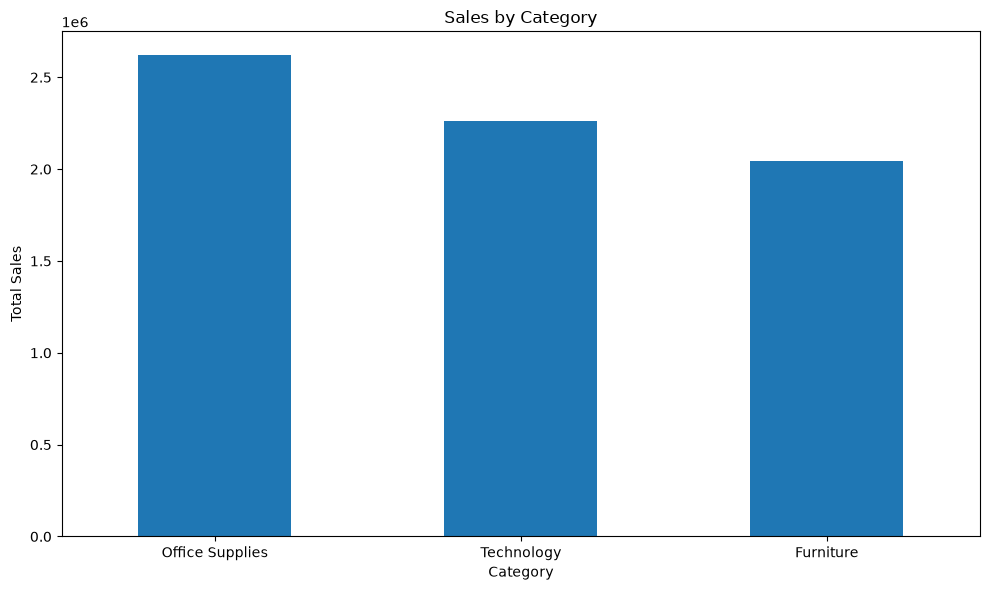

In [34]:
plt.figure(figsize=(10, 6))

category_sales.plot(kind="bar")

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig("../visualization/sales_by_category.png")

plt.show()

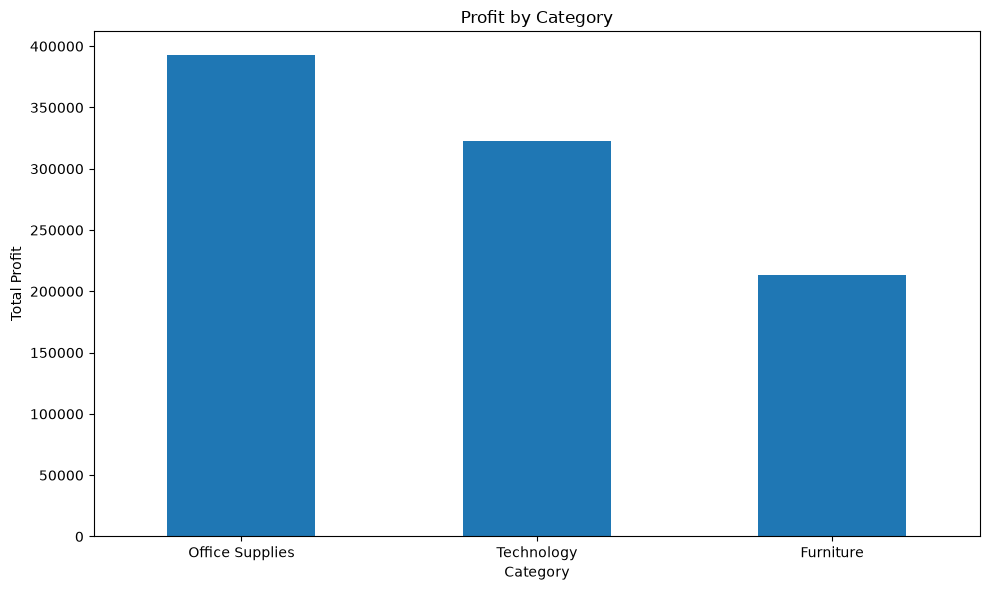

In [35]:
plt.figure(figsize=(10, 6))

category_profit.plot(kind="bar")

plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Total Profit")
plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig("../visualization/profit_by_category.png")

plt.show()

In [36]:
plt.figure(figsize=(10, 6))

region_sales.plot(kind="bar")

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("../visualization/sales_by_region.png")

plt.show()

NameError: name 'region_sales' is not defined

<Figure size 1000x600 with 0 Axes>

In [37]:
region_sales = df.groupby("region")["sales"].sum().sort_values(ascending=False)

print("Sales by Region:")
print(region_sales)

Sales by Region:
region
Central           1590434.5
South              915389.0
North              691905.0
Oceania            543524.0
EMEA               526291.0
Africa             489744.5
Southeast Asia     469889.5
North Asia         388592.0
West               377642.0
Central Asia       332285.5
East               323787.5
Caribbean          226363.5
Canada              46254.0
Name: sales, dtype: float64


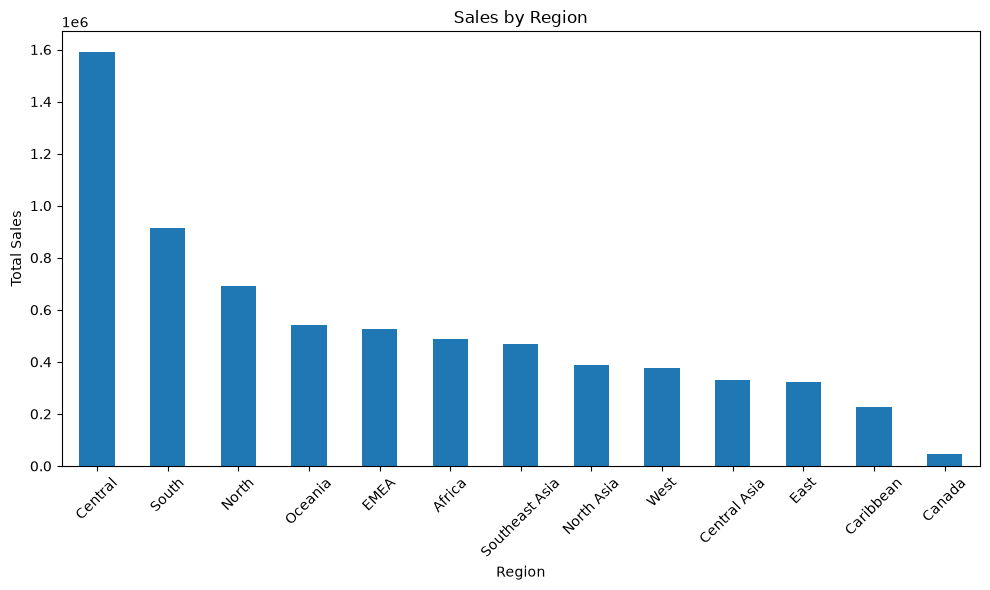

In [38]:
plt.figure(figsize=(10, 6))

region_sales.plot(kind="bar")

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("../visualization/sales_by_region.png")

plt.show()

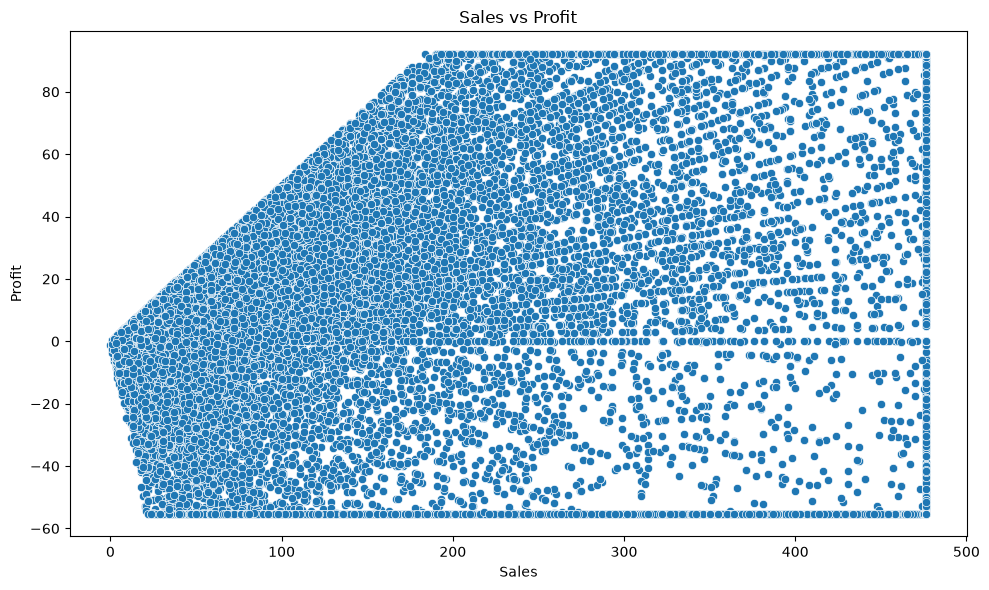

In [39]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="sales",
    y="profit"
)

plt.title("Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")

plt.tight_layout()
plt.savefig("../visualization/sales_vs_profit.png")

plt.show()

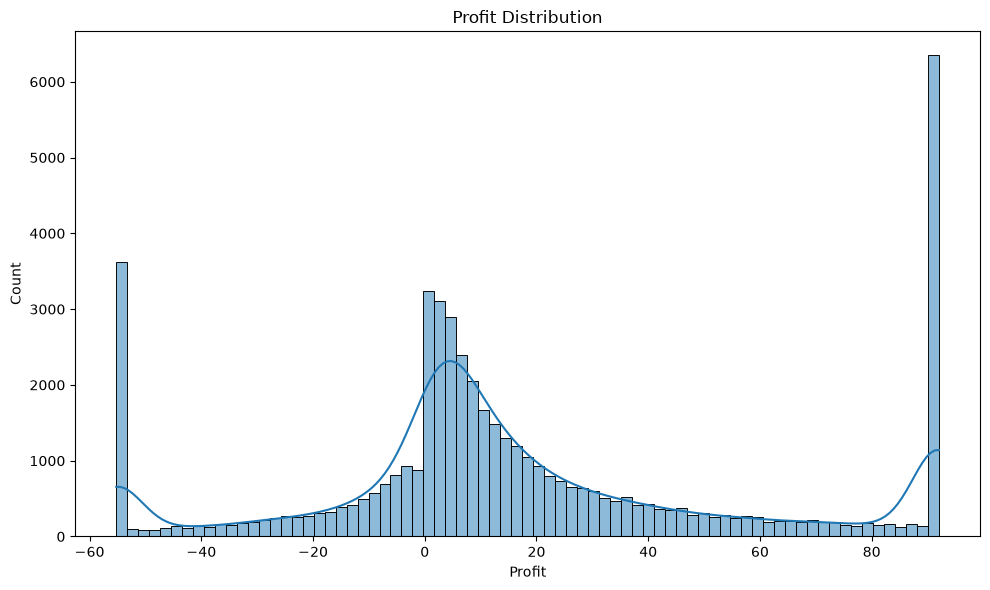

In [40]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="profit",
    kde=True
)

plt.title("Profit Distribution")
plt.xlabel("Profit")

plt.tight_layout()
plt.savefig("../visualization/profit_distribution.png")

plt.show()

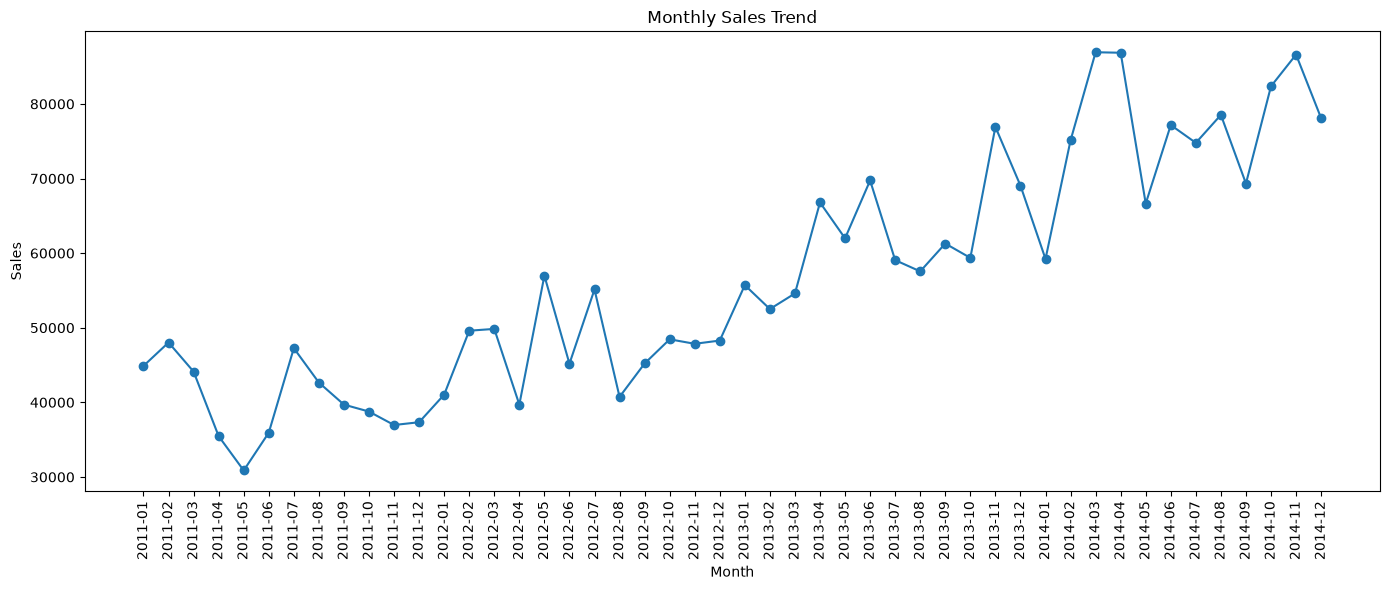

In [41]:
date_df = df.dropna(subset=["order_date"]).copy()

date_df["month"] = date_df["order_date"].dt.to_period("M")

monthly_sales = date_df.groupby("month")["sales"].sum()

plt.figure(figsize=(14, 6))

plt.plot(
    monthly_sales.index.astype(str),
    monthly_sales.values,
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.xticks(rotation=90)
plt.tight_layout()

plt.savefig("../visualization/monthly_sales_trend.png")

plt.show()

In [42]:
summary = pd.DataFrame({
    "Metric": [
        "Total Sales",
        "Total Profit",
        "Total Quantity Sold",
        "Average Sales"
    ],
    "Value": [
        round(df["sales"].sum(), 2),
        round(df["profit"].sum(), 2),
        df["quantity"].sum(),
        round(df["sales"].mean(), 2)
    ]
})

summary

,Metric,Value
0,Total Sales,6922102.00
1,Total Profit,928108.51
2,Total Quantity Sold,178312.00
3,Average Sales,142.25


In [43]:
best_category = df.groupby("category")["sales"].sum().idxmax()
best_region = df.groupby("region")["sales"].sum().idxmax()
best_profit_category = df.groupby("category")["profit"].sum().idxmax()

print("========== KEY INSIGHTS ==========\n")

print(f"1. Highest sales category: {best_category}")
print(f"2. Highest sales region: {best_region}")
print(f"3. Most profitable category: {best_profit_category}")
print(f"4. Total sales: {df['sales'].sum():,.2f}")
print(f"5. Total profit: {df['profit'].sum():,.2f}")
print(f"6. Total quantity sold: {df['quantity'].sum():,}")

print("\n===================================")

========== KEY INSIGHTS ==========

1. Highest sales category: Office Supplies
2. Highest sales region: Central
3. Most profitable category: Office Supplies
4. Total sales: 6,922,102.00
5. Total profit: 928,108.51
6. Total quantity sold: 178,312



In [14]:
print(df.columns.tolist())

['order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_name', 'segment', 'state', 'country', 'market', 'region', 'product_id', 'category', 'sub_category', 'product_name', 'sales', 'quantity', 'discount', 'profit', 'shipping_cost', 'order_priority', 'year']


In [1]:
print("My Data Cleaning and Visualization Project")


My Data Cleaning and Visualization Project
